# Athens Metro Line 1 — Ridership Data Pipeline

## Overview
This notebook fetches real ridership validation data from the [data.gov.gr](https://data.gov.gr),
cleans and filters it to **Line 1 (Kifissia–Piraeus)** weekday boardings, corrects a known
hour-binning offset, and exports structured Excel files for use in Power BI and the simulation notebook.

## Period
**16 February 2026 – 3 April 2026** (weekdays only, Greek public holidays included in raw fetch)

## Outputs
| File | Contents |
|---|---|
| `QFD.xlsx` | Full cleaned dataset |
| `QFD_Minimal.xlsx` | Grouped by date, weekday, hour |
| `QFD_Summary.xlsx` | Daily totals with sequential day counter |
| `QFD_Hourly.xlsx` | Daily totals grouped by hour |

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import requests
from datetime import datetime, timedelta
import random
import math
import json

In [2]:
#fetch ridership data from the OASA open data API (data.gov.gr)
#the API has a weekly limit per request, so we iterate week by week
url = 'https://data.gov.gr/api/v1/query/oasa_ridership'

start_date = datetime(2026, 2, 16)
end_date   = datetime(2026, 4, 4)

rideship_data = []

current = start_date

while current <= end_date:

    #check if the end_date is before the week_end
    week_end = current + timedelta(days=6)
    if week_end > end_date:
        week_end = end_date

    params = {
        "date_from": current.strftime("%Y-%m-%d"),
        "date_to": week_end.strftime("%Y-%m-%d")
    }

    response = requests.get(url, params=params)
    response.raise_for_status()

    data = response.json()
    rideship_data.extend(data)
    current = week_end + timedelta(days=1)

#create dataframe
rideship = pd.DataFrame(rideship_data)

In [3]:
rideship.head(3)

,dv_agency,dv_platenum_station,dv_validations,dv_route,routes_per_hour,load_dt,date_hour,etl_extraction_dt,etl_load_dt,dv_agency_desc,boarding_disembark_desc
0,002,ΠΕΙΡΑΙΑΣ,320,None,None,2026-02-16T07:53:12,2026-02-16T00:00:00,2026-02-15,2026-02-16,ΓΡΑΜΜΉ 1,Boarding
1,002,ΑΓΙΟΣ ΔΗΜΗTΡΙΟΣ,44,None,None,2026-02-16T07:53:12,2026-02-16T00:00:00,2026-02-15,2026-02-16,ΓΡΑΜΜΉ 2,Disembark
2,002,ΑΓΙΟΣ ΔΗΜΗTΡΙΟΣ,142,None,None,2026-02-16T07:53:12,2026-02-16T00:00:00,2026-02-15,2026-02-16,ΓΡΑΜΜΉ 2,Boarding


## Cleaning & Filtering

The raw API response includes both boarding and alighting events, all transit lines,
and several internal ETL metadata columns. The steps below narrow the dataset down to
only what is needed: **Line 1 boardings**.

In [4]:
#keep only boarding events (drop alightings — we measure ridership by entry)
rideship = rideship[rideship["boarding_disembark_desc"] == "Boarding"]
rideship = rideship.drop(columns=["boarding_disembark_desc"])

In [5]:
#filter dataset to only include metro lines
rideship = rideship[rideship['dv_agency_desc'] == 'ΓΡΑΜΜΉ 1']
rideship = rideship.drop(columns = ['dv_agency', 'dv_agency_desc', 'dv_route', 'routes_per_hour', 'etl_extraction_dt', 'etl_load_dt', 'load_dt'])

In [6]:
columns = ['station', 'validations', 'date_hour']
rideship.columns = columns

## Station Name Normalisation

The raw data mixes **Latin and Greek Unicode characters** for visually identical letters
(e.g. Latin `A` vs Greek `Α`). This causes the same station to appear as multiple distinct
values when grouping. The mapping below replaces all look-alike Latin characters with their
Greek equivalents, then upper-cases the result for consistency.

In [7]:
latin_to_greek = {
    "A": "Α",
    "B": "Β",
    "E": "Ε",
    "Z": "Ζ",
    "H": "Η",
    "I": "Ι",
    "K": "Κ",
    "M": "Μ",
    "N": "Ν",
    "O": "Ο",
    "P": "Ρ",
    "T": "Τ",
    "Y": "Υ",
    "X": "Χ"
}

def normalize_station_name(text):
    if pd.isna(text):
        return text
    
    text = str(text).strip()
    
    # Replace Latin chars with Greek
    for latin, greek in latin_to_greek.items():
        text = text.replace(latin, greek)
    
    # Normalize spaces
    text = " ".join(text.split())
    
    return text

rideship["station"] = rideship["station"].apply(normalize_station_name)
rideship["station"] = rideship["station"].str.upper()

## Datetime Parsing & Feature Extraction

`date_hour` is parsed into a proper datetime and decomposed into derived columns
used for grouping and filtering downstream.

In [8]:
rideship['date_hour'] = (
    pd.to_datetime(rideship['date_hour'])
)

#extract components from date_hour
rideship['trip_day'] = rideship['date_hour'].dt.normalize()
rideship['trip_hour'] = rideship['date_hour'].dt.hour
rideship['trip_weekday'] = rideship['date_hour'].dt.weekday
rideship['trip_month'] = rideship['date_hour'].dt.month

## Hour Offset Correction

The source data uses **ceiling binning**, for example, a validation at 13:30 is recorded under hour `14`,
not `13`. This shifts the entire hourly distribution one hour forward.

The fix subtracts 1 from every hour. The `% 24` handles the midnight edge case:
hour `0` (which represents 23:00–00:00 activity) correctly wraps to `23` instead of becoming `-1`.

In [9]:
rideship['trip_hour'] = (rideship['trip_hour']  - 1) % 24

## Weekday Filter

This analysis covers weekday operations only (Monday–Friday).
Weekend rows are dropped here.

In [10]:
# we only care about days of the week
rideship = rideship[rideship['date_hour'].dt.weekday < 5]

## Exploratory Visualisations

Quick sanity checks on the cleaned dataset before export.
After the hour correction, both peaks should align with known Line 1 patterns:
- **Morning peak:** ~09:00
- **Evening peak (dominant):** ~18:00

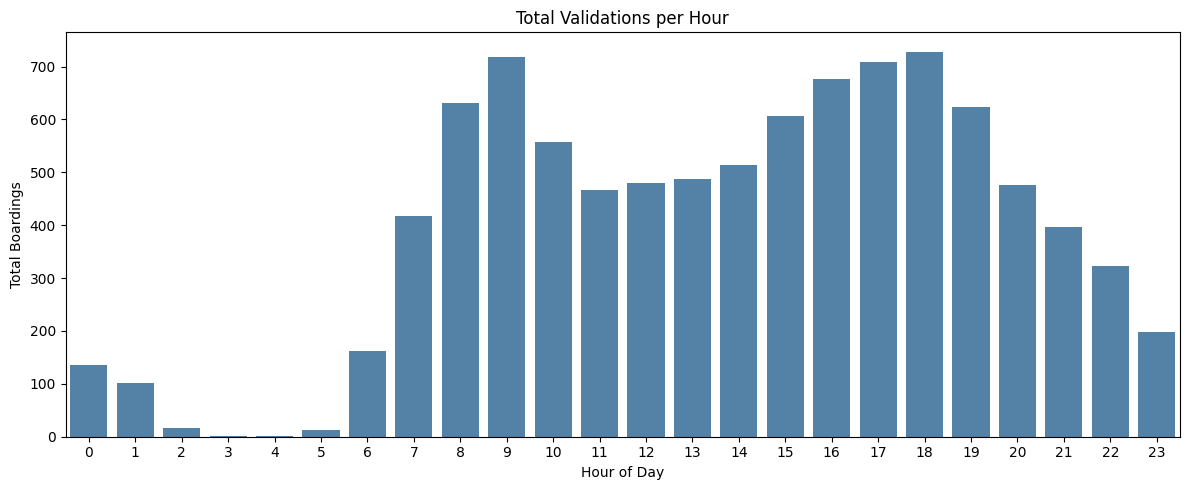

In [11]:
plt.figure(figsize=(12, 5))
sns.barplot(data=rideship, x='trip_hour', y='validations', color='steelblue', errorbar=None)

plt.title('Total Validations per Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Total Boardings')
plt.xticks(range(24))
plt.tight_layout()
plt.show()

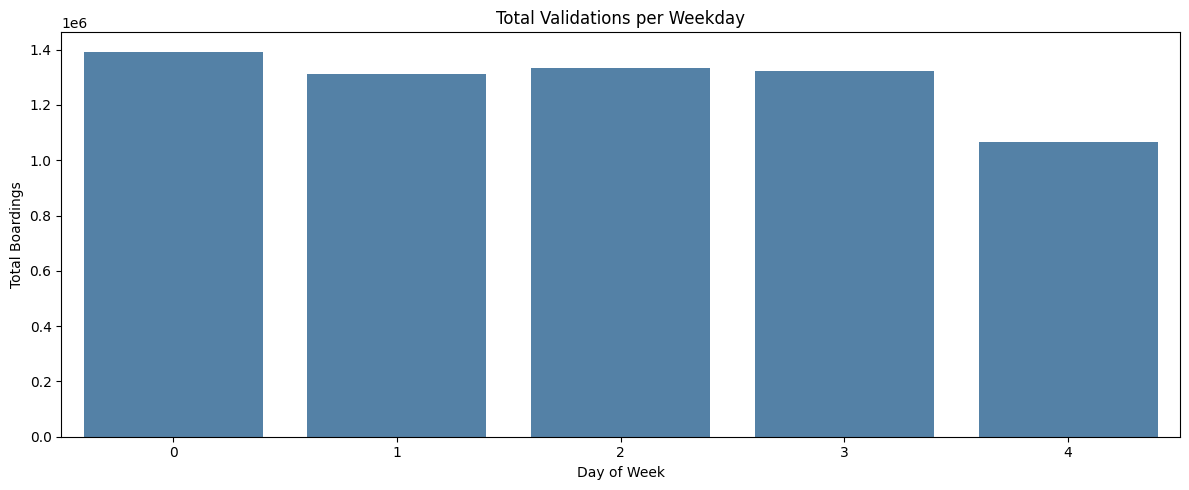

In [12]:
# Group by hour and sum validations
validations_per_hour = rideship.groupby('trip_weekday')['validations'].sum().reset_index()

# Plot
plt.figure(figsize=(12, 5))
sns.barplot(data=validations_per_hour, x='trip_weekday', y='validations', color='steelblue')

plt.title('Total Validations per Weekday')
plt.xlabel('Day of Week')
plt.ylabel('Total Boardings')
#plt.xticks(range(4))
plt.tight_layout()
plt.show()

In [13]:
daily = rideship.groupby('trip_weekday')['validations'].sum()
baseline = daily[2]  # Wednesday
day_multipliers_data = (daily / baseline).round(3)
print(day_multipliers_data)

# Then convert to list for your simulation:
day_multipliers = [day_multipliers_data[i] for i in range(5)]

trip_weekday
0    1.044
1    0.985
2    1.000
3    0.991
4    0.800
Name: validations, dtype: float64


In [32]:
station_order_map = {
    "ΚΗΦΙΣΙΑ": 1,
    "ΚΑΤ": 2,
    "ΜΑΡΟΥΣΙ": 3,
    "ΝΕΡΑΤΖΙΩΤΙΣΣΑ": 4,
    "ΕΙΡΗΝΗ": 5,
    "ΗΡΑΚΛΕΙΟ": 6,
    "ΝΕΑ ΙΩΝΙΑ": 7,
    "ΠΕΥΚΑΚΙΑ": 8,
    "ΠΕΡΙΣΣΟΣ": 9,
    "ΑΝΩ ΠΑΤΗΣΙΑ": 10,
    "ΑΓΙΟΣ ΕΛΕΥΘΕΡΙΟΣ": 11,
    "ΚΑΤΩ ΠΑΤΗΣΙΑ": 12,
    "ΑΓΙΟΣ ΝΙΚΟΛΑΟΣ": 13,
    "ΑΤΤΙΚΗ": 14,
    "ΒΙΚΤΩΡΙΑ": 15,
    "ΟΜΟΝΟΙΑ": 16,
    "ΜΟΝΑΣΤΗΡΑΚΙ": 17,
    "ΘΗΣΕΙΟ": 18,
    "ΠΕΤΡΑΛΩΝΑ": 19,
    "ΤΑΥΡΟΣ": 20,
    "ΚΑΛΛΙΘΕΑ": 21,
    "ΜΟΣΧΑΤΟ": 22,
    "ΦΑΛΗΡΟ": 23,
    "ΠΕΙΡΑΙΑΣ": 24,
}

rideship["station_order"] = rideship["station"].map(station_order_map).fillna(99).astype(int)

## Export

Four Excel files are exported for use in Power BI and the simulation notebook.

In [33]:
#full cleaned dataset — all stations, all hours, all weekdays
rideship.to_excel('QFD.xlsx', index=False)

In [27]:
rideship['station'].unique()

array(['ΠΕΙΡΑΙΑΣ', 'ΜΟΝΑΣΤΗΡΑΚΙ', 'ΦΑΛΗΡΟ', 'ΠΕΡΙΣΣΟΣ', 'ΚΗΦΙΣΙΑ',
       'ΗΡΑΚΛΕΙΟ', 'ΝΕΑ ΙΩΝΙΑ', 'ΝΕΡΑΤΖΙΩΤΙΣΣΑ', 'ΘΗΣΕΙΟ', 'ΒΙΚΤΩΡΙΑ',
       'ΚΑΤ', 'ΠΕΤΡΑΛΩΝΑ', 'ΑΓΙΟΣ ΕΛΕΥΘΕΡΙΟΣ', 'ΠΕΥΚΑΚΙΑ', 'ΑΝΩ ΠΑΤΗΣΙΑ',
       'ΚΑΤΩ ΠΑΤΗΣΙΑ', 'ΜΑΡΟΥΣΙ', 'ΑΓΙΟΣ ΝΙΚΟΛΑΟΣ', 'ΚΑΛΛΙΘΕΑ', 'ΕΙΡΗΝΗ',
       'ΜΟΣΧΑΤΟ', 'ΤΑΥΡΟΣ', 'ΟΜΟΝΟΙΑ', 'ΑΤΤΙΚΗ'], dtype=object)

In [15]:
rideship_minimal = rideship.groupby(['date_hour', 'trip_weekday', 'trip_hour'])['validations'].sum()

In [16]:
rideship_minimal.head()

date_hour            trip_weekday  trip_hour
2026-02-16 00:00:00  0             23           3783
2026-02-16 01:00:00  0             0            3428
2026-02-16 05:00:00  0             4               1
2026-02-16 06:00:00  0             5             237
2026-02-16 07:00:00  0             6            5051
Name: validations, dtype: int64

In [17]:
#minimal aggregation: total validations per (date, weekday, hour)
rideship_minimal.to_excel('QFD_Minimal.xlsx')

In [18]:
rideship_totals = (
    rideship.groupby(['trip_day', 'trip_weekday'])['validations']
    .sum()
    .reset_index()
)

In [19]:
rideship_totals['day_counter'] = list(range(len(rideship_totals)))

In [20]:
#daily totals per date
rideship_totals.to_excel('QFD_Summary.xlsx')

In [21]:
rideship_hourly = rideship.groupby(['trip_day', 'trip_hour'])['validations'].sum()

In [22]:
#hourly totals per day
rideship_hourly.to_excel('QFD_Hourly.xlsx')

In [23]:
#hourly demand weights
hourly_dist = rideship.groupby('trip_hour')['validations'].sum()
hourly_dist = (hourly_dist / hourly_dist.sum()).round(4)

#peak hours — any hour with demand 20% above average
mean_demand = hourly_dist.mean()
peak_hours = set(hourly_dist[hourly_dist > mean_demand * 1.4].index.tolist())

#disrupted days — days more than 1 std below average (proxy for incidents/cancellations)
daily_totals = rideship.groupby('trip_day')['validations'].sum()
mean_daily = daily_totals.mean()
std_daily  = daily_totals.std()
disrupted_days = daily_totals[daily_totals < mean_daily - 1.5 * std_daily]

sim_params = {
    "day_multipliers": day_multipliers,
    "hourly_weights": hourly_dist.to_dict(),
    "peak_hours": sorted(peak_hours),
    "incident_prob": round(len(disrupted_days) / len(daily_totals), 4),
}

with open("sim_params.json", "w") as f:
    json.dump(sim_params, f, indent=2)

print("sim_params.json saved")

sim_params.json saved
